# Revenue Sources: Black Hills vs Benchmark Regions

## Analysis notebook

This notebook answers the question:

> **For organizations filing Form 990, Form 990-EZ, or Form 990-PF, is there a difference in revenue sources between Black Hills and the benchmark regions?**

The notebook is organized as a report, not just a code script:

1. **Executive summary** gives the answer first.
2. **Data and variable lineage** explains the raw fields and every variable used.
3. **Validation checks** confirm the harmonized fields match the raw source fields.
4. **Analysis dataset construction** explains exclusions and revenue-source derivation.
5. **Charts** show the revenue-source mix overall and year by year.
6. **Statistical tests** show significance before and after FDR correction.
7. **Final interpretation** states the answer with and without FDR correction.


## Client question

**For the limited number of organizations filing Form 990, Form 990-EZ, or Form 990-PF: is there a difference in the revenue sources between Black Hills and benchmark regions?**

This notebook reproduces the report revenue-source analysis. It is written to be reviewable by a non-programmer while still showing the exact technical steps used to prepare the variables, test for differences, and produce the stacked bar charts.

The requested variables are:

| Requested variable | How this notebook uses it |
| --- | --- |
| **Total revenue** | The denominator for each organization's revenue-source shares. |
| **Program service revenue** | One of the named revenue-source categories. Available for Form 990 and Form 990-EZ; not comparable for Form 990-PF in this data source. |
| **Total contributions** | The contribution total reported by each filing type. Used directly and also used to place undecomposable 990-EZ/990-PF contributions into the mixed contribution bucket. |
| **Other contributions (foundation grants etc.)** | Not available as one clean field. The IRS fields split some institutional sources, but foundation grants, donor-advised funds, corporate gifts, bequests, and individual gifts can be mixed together. This notebook therefore labels the ambiguous portion as `mixed_other_contributions` rather than overclaiming it is only foundation grants. |

## Executive summary

The analysis finds evidence that revenue-source mix differs between Black Hills and the benchmark-region universe.

The strongest and most defensible direct finding is:

> **Black Hills organizations have a higher share of revenue from government grants received than the pooled benchmark regions.**

Before FDR correction, two additional source-share differences are significant at raw `p < 0.05`: Black Hills has lower likely-individual contribution share and lower residual other revenue share. After FDR correction, only government grants received share remains statistically significant. The notebook shows both views side by side.


The strongest finding is that **Black Hills organizations have a higher share of revenue from government grants received** than the pooled benchmark regions.

Across the broader five-region ANOVA, the revenue-source mix differs somewhere across the five regions. But in the direct **Black Hills vs pooled benchmark** comparison, after false discovery rate correction, **government grants received share is the only revenue-source share that remains statistically significant**.

## Technical setup

The next code cell imports the analysis libraries and defines file paths. It does not transform the data yet.

In [1]:
# Imports and notebook setup.
# These are standard Python analysis libraries: pandas/numpy for data work,
# scipy/statsmodels for Welch ANOVA, and matplotlib for charts.

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from statsmodels.stats.oneway import anova_oneway

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Find the repository root regardless of whether the notebook is executed from
# the repo root or from this notebook's folder.
def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'python' / 'analysis' / 'revenue_sources_black_hills').exists():
            return candidate
    raise RuntimeError('Could not find repository root from the current working directory.')

REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / 'data' / '321_Black_Hills_Area_Community_Foundation_2025_08' / '01_data'
STAGING_DIR = DATA_ROOT / 'staging' / 'filing'
ANALYSIS_DIR = DATA_ROOT / 'analysis' / 'revenue_sources_black_hills'
NOTEBOOK_OUTPUT_DIR = REPO_ROOT / 'python' / 'analysis' / 'revenue_sources_black_hills' / 'results' / 'client_notebook_assets'
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_BENCHMARK_PATH = STAGING_DIR / 'givingtuesday_990_basic_allforms_benchmark.parquet'
GT_ANALYSIS_PATH = STAGING_DIR / 'givingtuesday_990_basic_allforms_analysis_variables.parquet'

print(f'Repository root: {REPO_ROOT}')
print(f'Raw benchmark file: {RAW_BENCHMARK_PATH}')
print(f'Harmonized analysis-variable file: {GT_ANALYSIS_PATH}')

Repository root: C:\Users\eilke\Desktop\Github Repo\swb_project_321
Raw benchmark file: C:\Users\eilke\Desktop\Github Repo\swb_project_321\data\321_Black_Hills_Area_Community_Foundation_2025_08\01_data\staging\filing\givingtuesday_990_basic_allforms_benchmark.parquet
Harmonized analysis-variable file: C:\Users\eilke\Desktop\Github Repo\swb_project_321\data\321_Black_Hills_Area_Community_Foundation_2025_08\01_data\staging\filing\givingtuesday_990_basic_allforms_analysis_variables.parquet


## 1. Data sources and notebook setup

This section loads the raw benchmark file and the harmonized GivingTuesday analysis-variable file.

- The **raw benchmark file** keeps GivingTuesday source fields close to their original names, such as `TOTREVCURYEA`, `PROGSERVREVE`, and `CONGIFGRAETC`.
- The **harmonized analysis-variable file** standardizes those fields into analysis names such as `analysis_total_revenue_amount`, `analysis_program_service_revenue_amount`, and `analysis_total_contributions_amount`.


The raw benchmark parquet keeps the GivingTuesday fields close to their source names, such as `TOTREVCURYEA`, `PROGSERVREVE`, and `CONGIFGRAETC`.

The harmonized analysis-variable parquet is the cleaned layer used by the analysis. It keeps consistent variable names like `analysis_total_revenue_amount` and records which source column was used.

In [2]:
raw = pd.read_parquet(RAW_BENCHMARK_PATH)
gt = pd.read_parquet(GT_ANALYSIS_PATH)

summary = pd.DataFrame(
    [
        {'file': 'Raw benchmark parquet', 'rows': len(raw), 'columns': raw.shape[1]},
        {'file': 'Harmonized analysis variables', 'rows': len(gt), 'columns': gt.shape[1]},
    ]
)
display(summary)

display(
    gt['form_type']
    .value_counts()
    .rename_axis('form_type')
    .reset_index(name='rows')
    .sort_values('form_type')
)

,file,rows,columns
0,Raw benchmark parquet,4380,295
1,Harmonized analysis variables,4380,67


,form_type,rows
0,990,2439
1,990EZ,1429
2,990PF,512


## 2. Requested variables and raw-field lineage

The table below is the key data lineage for the four requested variables. This is a fixed documentation table because it explains the analysis design rather than calculating a result.

The correction worth noting is that **Form 990-EZ total contributions come from `CONGIFGRAETC`, not `TOTACASHCONT`**. In this raw benchmark file, `TOTACASHCONT` is a Form 990 contribution field and is blank for 990-EZ rows.

| Requested variable | Analysis variable | Form 990 source | Form 990-EZ source | Form 990-PF source | Notes |
| --- | --- | --- | --- | --- | --- |
| Total revenue | `analysis_total_revenue_amount` | `TOTREVCURYEA` | `TOTALRREVENU` | `ANREEXTOREEX` | Total revenue, form-aware because each filing type uses a different raw field. |
| Program service revenue | `analysis_program_service_revenue_amount` | `TOTPROSERREV` | `PROGSERVREVE` | Not comparable / missing | PF is kept missing because this GT extract does not provide a comparable PF program-service revenue concept. |
| Total contributions | `analysis_total_contributions_amount` | `TOTACASHCONT` | `CONGIFGRAETC` | `STREACGRTOIN` | Contribution total, form-aware. 990-EZ uses `CONGIFGRAETC`. |
| Other contributions (foundation grants etc.) | Partly decomposed; not one clean field | `GOVERNGRANTS`, `FEDERACAMPAI`, `RELATEORGANI`, `ALLOOTHECONT` | `CONGIFGRAETC` cannot be decomposed further here | `STREACGRTOIN` cannot be decomposed further here | Foundation grants are not isolated as a clean standalone field. Line 1f is mixed and can include individual gifts too. |



## 3. Variable dictionary: every variable used in the analysis

This section defines every variable used to answer the client question. The analysis has three layers of variables:

1. **Identifier and grouping variables** identify the organization, year, form type, and region.
2. **Revenue amount variables** measure dollars reported on the 990-family filings.
3. **Revenue-source share variables** divide each revenue-source amount by total revenue so organizations of different sizes can be compared fairly.

### Identifier and grouping variables

| Variable | Meaning | Why it is used |
| --- | --- | --- |
| `ein` | Employer Identification Number, standardized to 9 digits. | Identifies each organization. |
| `tax_year` | Filing tax year: 2022, 2023, or 2024. | Allows pooled and year-by-year analysis. |
| `form_type` | Filing type: `990`, `990EZ`, or `990PF`. | Determines which raw IRS/GivingTuesday fields are valid. |
| `region` | Raw benchmark-region code, such as `BlackHills` or `SiouxFalls`. | Used to assign organizations to the comparison geographies. |
| `region_label` | Readable region label, such as `Black Hills` or `Sioux Falls`. | Used in tables, charts, and five-region ANOVA. |
| `comparison_group` | `Black Hills` vs `Benchmark`. | Used for the direct client comparison. Benchmark pools Billings, Flagstaff, Missoula, and Sioux Falls. |

### Exclusion variables

| Variable | Meaning | Why it is used |
| --- | --- | --- |
| `is_hospital` | Flag for hospital-like organizations. | Excluded from the primary frame because the client is not a hospital. |
| `is_university` | Flag for university/school-like organizations. | Excluded from the primary frame because the client is not a university. |
| `is_political_org` | Flag for political organizations. | Excluded from the primary frame because the client is not a political organization. |

These exclusions make the primary comparison more peer-comparable. The broader analysis script also retains a full-universe sensitivity check, but this client notebook focuses on the primary peer-comparable frame.

### Requested headline revenue variables

| Notebook variable | Raw/harmonized source | Meaning | Important caveat |
| --- | --- | --- | --- |
| `total_revenue` | `analysis_total_revenue_amount`; raw fields are `TOTREVCURYEA` for 990, `TOTALRREVENU` for 990-EZ, and `ANREEXTOREEX` for 990-PF. | Total revenue reported by the organization. | This is the denominator for revenue-source shares. Rows must have positive total revenue to be included. |
| `program_service_revenue` | `analysis_program_service_revenue_amount`; raw fields are `TOTPROSERREV` for 990 and `PROGSERVREVE` for 990-EZ. | Revenue from program services. | Form 990-PF does not have a comparable value in this source, so PF program service revenue is kept missing and treated as 0 only for composition math. |
| `total_contributions` | `analysis_total_contributions_amount`; raw fields are `TOTACASHCONT` for 990, `CONGIFGRAETC` for 990-EZ, and `STREACGRTOIN` for 990-PF. | Total contributions, gifts, grants, and similar amounts. | 990-EZ total contributions must use `CONGIFGRAETC`; `TOTACASHCONT` is blank for 990-EZ in this raw source. |
| `mixed_other_contributions` | Form 990 `ALLOOTHECONT`; full `total_contributions` for 990-EZ and 990-PF. | The best available bucket for other contributions, including possible foundation grants. | This is not pure foundation grants. It may mix individual gifts, private foundation grants, donor-advised fund distributions, corporate gifts, bequests, and other contribution types. |

### Form 990 contribution subcomponent variables

The Form 990 has more detailed contribution lines than 990-EZ and 990-PF. The analysis uses these lines to split total contributions where possible.

| Notebook variable | Raw/harmonized source | Meaning | How it enters the analysis |
| --- | --- | --- | --- |
| `federated_campaigns` | `analysis_federated_campaigns_amount`, raw `FEDERACAMPAI`. | Form 990 Line 1a, federated campaigns. | Added to `other_institutional_contributions`. |
| `membership_dues` | `analysis_membership_dues_amount`, raw `MEMBERDUESUE`. | Form 990 Line 1b membership dues; also appears on 990-EZ as a separate revenue line. | For Form 990 only, included in `individual_likely_contributions`. For 990-EZ it remains in residual revenue rather than being treated as a contribution subcomponent. |
| `fundraising_events_contributions` | `analysis_fundraising_events_contributions_amount`, raw `FUNDRAEVENTS`. | Form 990 Line 1c contributions from fundraising events. | Added to `individual_likely_contributions`. |
| `related_org_contributions` | `analysis_related_org_contributions_amount`, raw `RELATEORGANI`. | Form 990 Line 1d contributions from related organizations. | Added to `other_institutional_contributions`. |
| `government_grants` | `analysis_government_grants_amount`, raw `GOVERNGRANTS`. | Form 990 Line 1e government grants received. | Used as `government_grants_received`. |
| `allo_other_contributions_line_1f` | `analysis_other_contributions_amount`, raw `ALLOOTHECONT`. | Form 990 Line 1f all other contributions, gifts, grants, and similar amounts. | Used as the Form 990 part of `mixed_other_contributions`. |

### Final mutually exclusive revenue-source components

These six components are the variables used in the stacked bar charts and the main source-share ANOVAs.

| Component | Construction | Interpretation |
| --- | --- | --- |
| `program_service_revenue` | 990/EZ program service revenue; PF missing handled as 0 for composition. | Revenue earned from programs or services. |
| `government_grants_received` | Form 990 `government_grants`; 0 for 990-EZ/PF. | Clearly identified government grant revenue. |
| `other_institutional_contributions` | Form 990 `federated_campaigns + related_org_contributions`; 0 for 990-EZ/PF. | Institutional contribution channels that can be separated from individuals. |
| `individual_likely_contributions` | Form 990 `membership_dues + fundraising_events_contributions`; 0 for 990-EZ/PF. | Conservative proxy for likely individual giving. It is not a perfect individual-giving measure. |
| `mixed_other_contributions` | Form 990 `ALLOOTHECONT`; full total contributions for 990-EZ/PF. | Undecomposable contribution bucket, including possible foundation grants but not limited to them. |
| `residual_other_revenue` | `total_revenue - program_service_revenue - contribution source components`. | All remaining revenue not captured by the named categories. Negative residuals can happen because of reporting/timing/category overlap; they are clipped to zero only for composition plots. |

### Share variables used in the main ANOVA

Each share variable is calculated as:

```text
component_share = component_amount / total_revenue
```

| Share variable | Numerator | Denominator | Main interpretation |
| --- | --- | --- | --- |
| `program_service_revenue_share` | `program_service_revenue` | `total_revenue` | Share of revenue from program services. |
| `government_grants_received_share` | `government_grants_received` | `total_revenue` | Share of revenue from government grants. |
| `other_institutional_contributions_share` | `other_institutional_contributions` | `total_revenue` | Share from clearly institutional non-government contribution channels. |
| `individual_likely_contributions_share` | `individual_likely_contributions` | `total_revenue` | Share from conservative likely-individual contribution channels. |
| `mixed_other_contributions_share` | `mixed_other_contributions` | `total_revenue` | Share from undecomposable other contributions, including possible foundation grants. |
| `residual_other_revenue_share` | `residual_other_revenue`, clipped at 0 for composition use | `total_revenue` | Share from all other revenue not assigned above. |

### Log-transformed amount variables used in secondary tests

The main client question is about revenue-source **mix**, so the share variables above are primary. The notebook also tests selected amount variables after applying `log1p`, meaning:

```text
log1p(x) = ln(1 + x)
```

This transformation reduces the influence of very large organizations and allows zero-dollar values to remain in the analysis.

| Log variable | Original amount | Why it is included |
| --- | --- | --- |
| `log1p_total_revenue` | `total_revenue` | Tests whether typical revenue scale differs by group. |
| `log1p_program_service_revenue` | `program_service_revenue` | Tests whether program service revenue levels differ by group. |
| `log1p_total_contributions` | `total_contributions` | Tests whether total contribution levels differ by group. |
| `log1p_government_grants_received` | `government_grants_received` | Tests whether government grant dollar levels differ by group. |
| `log1p_mixed_other_contributions` | `mixed_other_contributions` | Tests whether mixed other contribution dollar levels differ by group. |

These amount-level tests are secondary because they answer a different question from the source-mix analysis. A region can have different dollar levels without having a different revenue-source share, and vice versa.


## 4. Data validation checks

This section verifies that the harmonized variables used in the analysis match the intended raw source fields row by row. These checks are computed rather than written as static documentation.


This check compares the harmonized variables against the raw source columns row by row. A mismatch count of zero means the harmonized variable exactly matches the intended raw field for that form type.

In [3]:
# The raw and harmonized files have the same row order and no duplicate keys.
key_cols = ['ein', 'tax_year', 'form_type', 'region']
same_key_order = gt[key_cols].astype(str).reset_index(drop=True).equals(raw[key_cols].astype(str).reset_index(drop=True))
print(f'Same row order by key columns: {same_key_order}')
print(f'Duplicate keys in raw file: {raw.duplicated(key_cols).sum():,}')
print(f'Duplicate keys in harmonized file: {gt.duplicated(key_cols).sum():,}')

source_cols = [
    'TOTREVCURYEA', 'TOTALRREVENU', 'ANREEXTOREEX',
    'TOTPROSERREV', 'PROGSERVREVE',
    'TOTACASHCONT', 'CONGIFGRAETC', 'STREACGRTOIN',
]
check = gt.reset_index(drop=True).join(raw[source_cols].reset_index(drop=True).add_suffix('_raw'))

def numeric(series):
    return pd.to_numeric(series, errors='coerce')

def mismatch_count(output_col, form_type, source_col):
    mask = check['form_type'].astype(str).str.upper().eq(form_type)
    observed = numeric(check.loc[mask, output_col])
    expected = numeric(check.loc[mask, source_col])
    both_missing = observed.isna() & expected.isna()
    matched = both_missing | observed.fillna(0).sub(expected.fillna(0)).abs().le(1e-9)
    return {
        'analysis_variable': output_col,
        'form_type': form_type,
        'raw_source_column': source_col.replace('_raw', ''),
        'rows_checked': int(mask.sum()),
        'nonmissing_analysis_values': int(observed.notna().sum()),
        'nonmissing_raw_values': int(expected.notna().sum()),
        'mismatches': int((~matched).sum()),
    }

mapping_checks = pd.DataFrame([
    mismatch_count('analysis_total_revenue_amount', '990', 'TOTREVCURYEA_raw'),
    mismatch_count('analysis_total_revenue_amount', '990EZ', 'TOTALRREVENU_raw'),
    mismatch_count('analysis_total_revenue_amount', '990PF', 'ANREEXTOREEX_raw'),
    mismatch_count('analysis_program_service_revenue_amount', '990', 'TOTPROSERREV_raw'),
    mismatch_count('analysis_program_service_revenue_amount', '990EZ', 'PROGSERVREVE_raw'),
    mismatch_count('analysis_total_contributions_amount', '990', 'TOTACASHCONT_raw'),
    mismatch_count('analysis_total_contributions_amount', '990EZ', 'CONGIFGRAETC_raw'),
    mismatch_count('analysis_total_contributions_amount', '990PF', 'STREACGRTOIN_raw'),
])

display(mapping_checks)

Same row order by key columns: True
Duplicate keys in raw file: 0
Duplicate keys in harmonized file: 0


,analysis_variable,form_type,raw_source_column,rows_checked,nonmissing_analysis_values,nonmissing_raw_values,mismatches
0,analysis_total_revenue_amount,990,TOTREVCURYEA,2439,2439,2439,0
1,analysis_total_revenue_amount,990EZ,TOTALRREVENU,1429,1416,1416,0
2,analysis_total_revenue_amount,990PF,ANREEXTOREEX,512,512,512,0
3,analysis_program_service_revenue_amount,990,TOTPROSERREV,2439,1772,1772,0
4,analysis_program_service_revenue_amount,990EZ,PROGSERVREVE,1429,769,769,0
5,analysis_total_contributions_amount,990,TOTACASHCONT,2439,2191,2191,0
6,analysis_total_contributions_amount,990EZ,CONGIFGRAETC,1429,1191,1191,0
7,analysis_total_contributions_amount,990PF,STREACGRTOIN,512,178,178,0


## 5. Build the peer-comparable analysis dataset

This section constructs the analysis dataset used for charts and statistical tests. It keeps 2022, 2023, and 2024; requires positive total revenue; and excludes hospitals, universities, and political organizations from the primary comparison because the client is not one of those organization types.


The analysis is done at the organization-year filing level. We keep 2022, 2023, and 2024; require positive total revenue; and exclude hospitals, universities, and political organizations from the primary client-peer comparison because the client is not one of those organization types.

The source categories are designed to be mutually exclusive for plotting:

| Component | Meaning |
| --- | --- |
| `program_service_revenue` | Program service revenue from 990/990-EZ. |
| `government_grants_received` | Form 990 government grants received. |
| `other_institutional_contributions` | Form 990 federated campaigns plus related-organization contributions. |
| `individual_likely_contributions` | Form 990 membership dues plus fundraising-event contributions. |
| `mixed_other_contributions` | Form 990 Line 1f plus undecomposable 990-EZ and 990-PF total contributions. This is where many foundation/corporate/DAF gifts may sit, but it can also include individual gifts. |
| `residual_other_revenue` | Revenue not allocated to the named categories. |

In [4]:
REGION_LABELS = {
    'BlackHills': 'Black Hills',
    'SiouxFalls': 'Sioux Falls',
    'Billings': 'Billings',
    'Flagstaff': 'Flagstaff',
    'Missoula': 'Missoula',
}

SOURCE_COMPONENTS = [
    'program_service_revenue',
    'government_grants_received',
    'other_institutional_contributions',
    'individual_likely_contributions',
    'mixed_other_contributions',
    'residual_other_revenue',
]
SHARE_COMPONENTS = [f'{column}_share' for column in SOURCE_COMPONENTS]

def first_existing_column(frame, candidates):
    for column in candidates:
        if column in frame.columns:
            return frame[column]
    return pd.Series([pd.NA] * len(frame), index=frame.index)

def normalize_bool(series):
    true_values = {'1', 'Y', 'YES', 'TRUE', 'T'}
    false_values = {'0', 'N', 'NO', 'FALSE', 'F'}
    def convert(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper()
        if text in true_values:
            return True
        if text in false_values:
            return False
        return pd.NA
    return series.map(convert).astype('boolean')

def prepare_revenue_source_frame(frame):
    out = pd.DataFrame(index=frame.index)
    out['ein'] = first_existing_column(frame, ['ein']).astype(str).str.zfill(9)
    out['tax_year'] = first_existing_column(frame, ['tax_year']).astype(str)
    out['form_type'] = first_existing_column(frame, ['form_type']).astype(str).str.upper().str.strip()
    out['region'] = first_existing_column(frame, ['region']).astype(str).str.strip()
    out['region_label'] = out['region'].map(REGION_LABELS).fillna(out['region'])
    out['comparison_group'] = np.where(out['region'].eq('BlackHills'), 'Black Hills', 'Benchmark')

    # Requested headline variables.
    out['total_revenue'] = numeric(first_existing_column(frame, ['analysis_total_revenue_amount']))
    out['program_service_revenue'] = numeric(first_existing_column(frame, ['analysis_program_service_revenue_amount']))
    out['total_contributions'] = numeric(first_existing_column(frame, ['analysis_total_contributions_amount']))

    # Detailed contribution fields. These are available mainly for Form 990.
    out['federated_campaigns'] = numeric(first_existing_column(frame, ['analysis_federated_campaigns_amount']))
    out['membership_dues'] = numeric(first_existing_column(frame, ['analysis_membership_dues_amount']))
    out['fundraising_events_contributions'] = numeric(first_existing_column(frame, ['analysis_fundraising_events_contributions_amount']))
    out['related_org_contributions'] = numeric(first_existing_column(frame, ['analysis_related_org_contributions_amount']))
    out['government_grants'] = numeric(first_existing_column(frame, ['analysis_government_grants_amount']))
    out['allo_other_contributions_line_1f'] = numeric(first_existing_column(frame, ['analysis_other_contributions_amount']))

    # Exclusion flags for the primary client-peer comparison.
    out['is_hospital'] = normalize_bool(first_existing_column(frame, ['analysis_imputed_is_hospital', 'analysis_is_hospital']))
    out['is_university'] = normalize_bool(first_existing_column(frame, ['analysis_imputed_is_university', 'analysis_is_university']))
    out['is_political_org'] = normalize_bool(first_existing_column(frame, ['analysis_imputed_is_political_org', 'analysis_is_political_org']))

    # 990-PF has no comparable program service revenue field in this source.
    out.loc[out['form_type'].eq('990PF'), 'program_service_revenue'] = np.nan

    is_form_990 = out['form_type'].eq('990')

    # Contribution decomposition. Only Form 990 exposes the same Line 1 subcomponents.
    out['government_grants_received'] = np.where(is_form_990, out['government_grants'].fillna(0), 0)
    out['other_institutional_contributions'] = np.where(
        is_form_990,
        out['federated_campaigns'].fillna(0) + out['related_org_contributions'].fillna(0),
        0,
    )
    out['individual_likely_contributions'] = np.where(
        is_form_990,
        out['membership_dues'].fillna(0) + out['fundraising_events_contributions'].fillna(0),
        0,
    )
    out['mixed_other_contributions'] = np.where(
        is_form_990,
        out['allo_other_contributions_line_1f'].fillna(0),
        out['total_contributions'].fillna(0),
    )

    contribution_segment_sum = (
        out['government_grants_received']
        + out['other_institutional_contributions']
        + out['individual_likely_contributions']
        + out['mixed_other_contributions']
    )
    out['residual_other_revenue'] = out['total_revenue'] - out['program_service_revenue'].fillna(0) - contribution_segment_sum

    # Keep the primary analytic universe.
    out = out.loc[out['tax_year'].isin(['2022', '2023', '2024'])].copy()
    out = out.loc[out['total_revenue'].notna() & out['total_revenue'].gt(0)].copy()
    out = out.loc[out['region'].notna() & out['region'].ne('')].copy()
    out = out.loc[~(out['is_hospital'].fillna(False) | out['is_university'].fillna(False) | out['is_political_org'].fillna(False))].copy()

    # Shares are organization-level proportions of total revenue.
    for component in SOURCE_COMPONENTS:
        numerator = out[component].copy()
        # Negative residuals are kept in diagnostics elsewhere, but clipped for composition plots/tests.
        if component == 'residual_other_revenue':
            numerator = numerator.clip(lower=0)
        out[f'{component}_share'] = numerator / out['total_revenue']

    # Amount-level variables are log transformed for secondary tests because dollar amounts are highly skewed.
    for column in ['total_revenue', 'program_service_revenue', 'total_contributions'] + SOURCE_COMPONENTS:
        out[f'log1p_{column}'] = np.log1p(out[column].clip(lower=0))

    return out.reset_index(drop=True)

analysis = prepare_revenue_source_frame(gt)
print(f'Primary analysis rows after filters/exclusions: {len(analysis):,}')
print(f'Flagged hospital/university/political rows remaining: {int((analysis["is_hospital"].fillna(False) | analysis["is_university"].fillna(False) | analysis["is_political_org"].fillna(False)).sum()):,}')

display(
    analysis.groupby(['comparison_group', 'tax_year', 'form_type'])
    .size()
    .rename('rows')
    .reset_index()
    .sort_values(['comparison_group', 'tax_year', 'form_type'])
)

Primary analysis rows after filters/exclusions: 4,179
Flagged hospital/university/political rows remaining: 0


,comparison_group,tax_year,form_type,rows
0,Benchmark,2022,990,829
1,Benchmark,2022,990EZ,422
2,Benchmark,2022,990PF,126
3,Benchmark,2023,990,791
4,Benchmark,2023,990EZ,402
5,Benchmark,2023,990PF,199
6,Benchmark,2024,990,177
7,Benchmark,2024,990EZ,198
8,Benchmark,2024,990PF,36
9,Black Hills,2022,990,256


## 6. Stacked bar charts: revenue-source mix

The stacked bars show the **aggregate dollar mix**, normalized so each bar sums to 100%. This is the clearest visual presentation of the revenue-source composition.

These charts should be read together with the ANOVA tables because a stacked dollar chart can be influenced by very large organizations, while the ANOVA tests organization-level shares.


The stacked bars show the **aggregate dollar mix**, normalized so each bar sums to 100%. This is useful for presentation because it shows how revenue dollars are distributed across sources. It should be read alongside the ANOVA tables, which test organization-level shares.

comparison_group,Benchmark,Black Hills
component_label,,
Program service revenue,59.4000,37.4000
Government grants received,9.3000,26.5000
Other institutional contributions,1.6000,1.5000
Likely individual contributions,1.0000,0.6000
Mixed other contributions,17.7000,24.5000
Residual other revenue,11.0000,9.5000


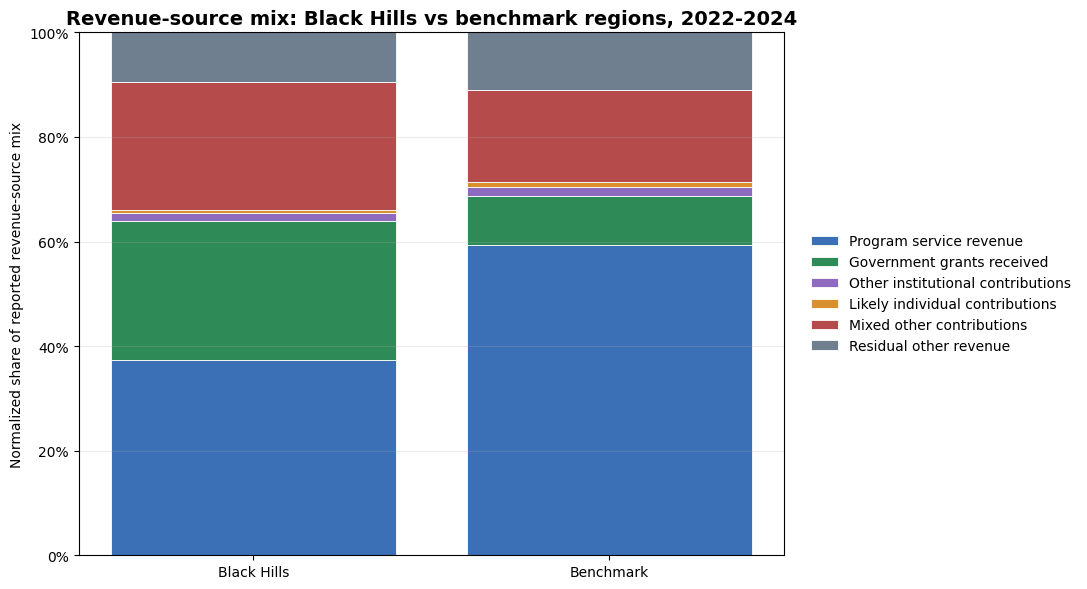

Saved chart to: C:\Users\eilke\Desktop\Github Repo\swb_project_321\python\analysis\revenue_sources_black_hills\results\client_notebook_assets\client_stacked_revenue_mix_black_hills_vs_benchmark.png


In [5]:
DISPLAY_LABELS = {
    'program_service_revenue': 'Program service revenue',
    'government_grants_received': 'Government grants received',
    'other_institutional_contributions': 'Other institutional contributions',
    'individual_likely_contributions': 'Likely individual contributions',
    'mixed_other_contributions': 'Mixed other contributions',
    'residual_other_revenue': 'Residual other revenue',
}

COLORS = {
    'Program service revenue': '#3B6FB6',
    'Government grants received': '#2E8B57',
    'Other institutional contributions': '#8E6BBE',
    'Likely individual contributions': '#D8902F',
    'Mixed other contributions': '#B64B4B',
    'Residual other revenue': '#6F7F8F',
}

def aggregate_mix(frame, group_cols):
    rows = []
    for keys, group in frame.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        component_amounts = {}
        for component in SOURCE_COMPONENTS:
            values = group[component].copy()
            if component == 'residual_other_revenue':
                values = values.clip(lower=0)
            component_amounts[component] = values.fillna(0).sum()
        total_components = sum(component_amounts.values())
        for component, amount in component_amounts.items():
            row = dict(zip(group_cols, keys))
            row.update({
                'component': component,
                'component_label': DISPLAY_LABELS[component],
                'amount': amount,
                'normalized_mix_share': amount / total_components if total_components else np.nan,
            })
            rows.append(row)
    return pd.DataFrame(rows)

def plot_stacked_mix(mix_df, x_col, title, output_name, order=None, x_labels=None, figsize=(11, 6), rotation=0):
    pivot = mix_df.pivot(index=x_col, columns='component_label', values='normalized_mix_share').fillna(0)
    component_order = [DISPLAY_LABELS[c] for c in SOURCE_COMPONENTS]
    if order is not None:
        pivot = pivot.loc[order]
    else:
        pivot = pivot.sort_index()
    pivot = pivot[component_order]

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(pivot))
    x_positions = np.arange(len(pivot))
    for label in component_order:
        values = pivot[label].values
        ax.bar(x_positions, values, bottom=bottom, label=label, color=COLORS[label], edgecolor='white', linewidth=0.6)
        bottom += values

    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_ylabel('Normalized share of reported revenue-source mix')
    ax.set_ylim(0, 1)
    ax.set_xticks(x_positions)
    labels = x_labels if x_labels is not None else list(pivot.index)
    ax.set_xticklabels(labels, rotation=rotation, ha='center')
    ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()

    output_path = NOTEBOOK_OUTPUT_DIR / output_name
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved chart to: {output_path}')

mix_by_group = aggregate_mix(analysis, ['comparison_group'])
display(
    mix_by_group
    .assign(percent=lambda d: d['normalized_mix_share'] * 100)
    .pivot(index='component_label', columns='comparison_group', values='percent')
    .loc[[DISPLAY_LABELS[c] for c in SOURCE_COMPONENTS]]
    .round(1)
)

plot_stacked_mix(
    mix_by_group,
    x_col='comparison_group',
    title='Revenue-source mix: Black Hills vs benchmark regions, 2022-2024',
    output_name='client_stacked_revenue_mix_black_hills_vs_benchmark.png',
    order=['Black Hills', 'Benchmark'],
)

## 6.1 Year-by-year stacked bar chart

This chart shows whether the aggregate mix pattern is stable across tax years. Each bar is a comparison group within a year.


This chart shows whether the aggregate mix pattern is stable across tax years. Each bar is a comparison group within a year.

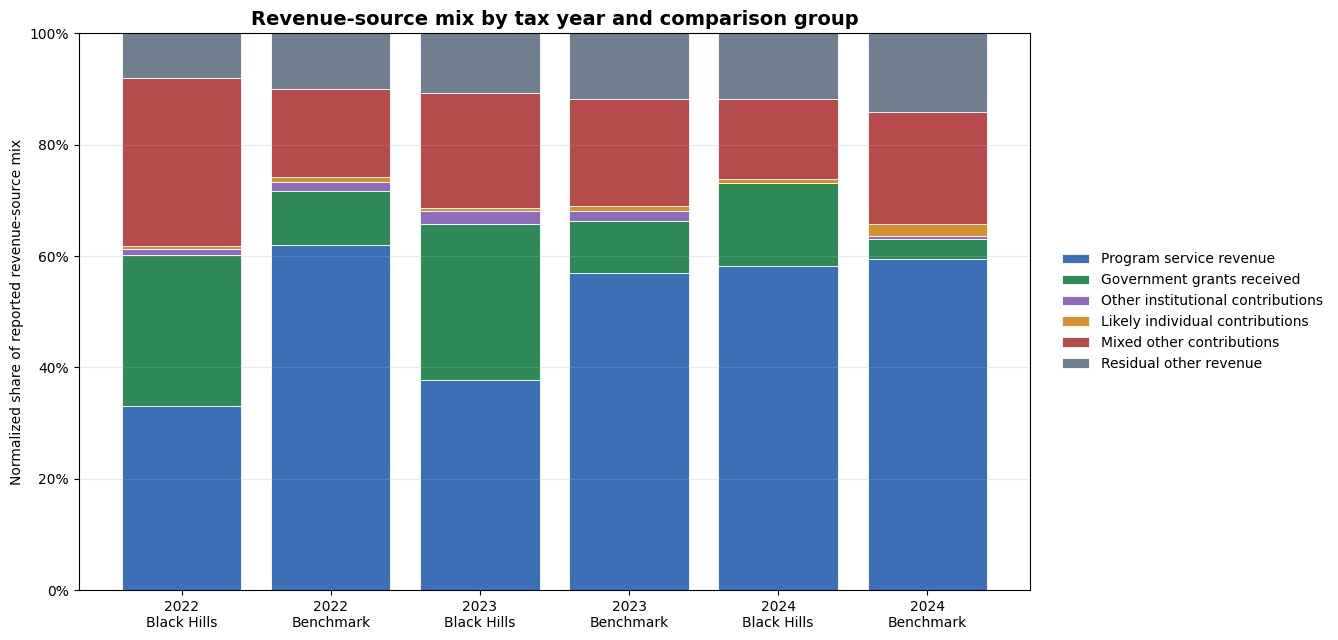

Saved chart to: C:\Users\eilke\Desktop\Github Repo\swb_project_321\python\analysis\revenue_sources_black_hills\results\client_notebook_assets\client_stacked_revenue_mix_by_year.png


In [6]:
mix_by_year = aggregate_mix(analysis, ['tax_year', 'comparison_group'])

# Use compact two-line labels so the six bars are readable in a client-facing notebook.
# The underlying grouping remains year + comparison group; only the display labels change.
mix_by_year['year_group'] = mix_by_year['tax_year'].astype(str) + '|' + mix_by_year['comparison_group']
order = [f'{year}|{group}' for year in ['2022', '2023', '2024'] for group in ['Black Hills', 'Benchmark']]
label_map = {
    f'{year}|Black Hills': f'{year}\nBlack Hills'
    for year in ['2022', '2023', '2024']
}
label_map.update({
    f'{year}|Benchmark': f'{year}\nBenchmark'
    for year in ['2022', '2023', '2024']
})

plot_stacked_mix(
    mix_by_year,
    x_col='year_group',
    title='Revenue-source mix by tax year and comparison group',
    output_name='client_stacked_revenue_mix_by_year.png',
    order=order,
    x_labels=[label_map[item] for item in order],
    figsize=(13.5, 6.5),
)

## 7. Statistical testing method and ANOVA results

The main test is **Welch ANOVA** on organization-level revenue-source shares.

Why Welch ANOVA?

- Revenue-source shares are compared across groups.
- The groups do not have exactly equal variances or equal sample sizes.
- Welch ANOVA is more robust than ordinary ANOVA when variances differ.

We run two versions:

1. **Five-region test:** Black Hills, Billings, Flagstaff, Missoula, and Sioux Falls separately. This asks whether revenue-source shares differ somewhere across the region set.
2. **Black Hills vs pooled benchmark test:** Black Hills compared directly with all benchmark regions pooled together. This answers the client-facing comparison most directly.

Because we test several source-share variables, we also report **FDR-adjusted p-values** using the Benjamini-Hochberg method. FDR correction reduces the chance of treating a random false positive as a real finding when multiple variables are tested.

The ANOVA tables show two significance columns:

| Column | Meaning |
| --- | --- |
| `significant_before_fdr` | Whether the raw p-value is below 0.05 before multiple-testing adjustment. This is useful for transparency but is more vulnerable to false positives when many variables are tested. |
| `significant_after_fdr` | Whether the Benjamini-Hochberg FDR-adjusted p-value is below 0.05. This is the more conservative result used for the main conclusion. |


In [7]:
def fdr_bh(p_values):
    """Benjamini-Hochberg false discovery rate adjusted p-values."""
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p, np.nan, dtype=float)
    valid = ~np.isnan(p)
    valid_p = p[valid]
    if len(valid_p) == 0:
        return adjusted

    order = np.argsort(valid_p)
    ranked = valid_p[order]
    m = len(ranked)
    raw_adjusted = ranked * m / np.arange(1, m + 1)
    monotone = np.minimum.accumulate(raw_adjusted[::-1])[::-1]
    monotone = np.clip(monotone, 0, 1)

    valid_indices = np.where(valid)[0]
    adjusted[valid_indices[order]] = monotone
    return adjusted

def welch_anova_table(frame, variables, group_col):
    rows = []
    for variable in variables:
        sub = frame[[group_col, variable]].dropna().copy()
        groups = [group[variable].to_numpy() for _, group in sub.groupby(group_col) if len(group) >= 2]
        if len(groups) < 2:
            statistic = np.nan
            p_value = np.nan
        else:
            result = anova_oneway(groups, use_var='unequal')
            statistic = float(result.statistic)
            p_value = float(result.pvalue)
        rows.append({
            'variable': variable,
            'welch_statistic': statistic,
            'p_value': p_value,
            'n': len(sub),
        })
    out = pd.DataFrame(rows)
    out['significant_before_fdr'] = np.where(out['p_value'].lt(0.05), 'Yes', 'No')
    out['fdr_p_value'] = fdr_bh(out['p_value'].to_numpy())
    out['significant_after_fdr'] = np.where(out['fdr_p_value'].lt(0.05), 'Yes', 'No')
    return out

five_region_anova = welch_anova_table(analysis, SHARE_COMPONENTS, 'region_label')
bh_vs_benchmark_anova = welch_anova_table(analysis, SHARE_COMPONENTS, 'comparison_group')

# Add Black Hills vs benchmark direction for the direct comparison table.
share_means = analysis.groupby('comparison_group')[SHARE_COMPONENTS].mean()
def direction(variable):
    bh = share_means.loc['Black Hills', variable]
    bm = share_means.loc['Benchmark', variable]
    if math.isclose(bh, bm, rel_tol=0, abs_tol=0.001):
        return 'No meaningful difference'
    return 'Black Hills higher' if bh > bm else 'Black Hills lower'

bh_vs_benchmark_anova['direction'] = bh_vs_benchmark_anova['variable'].map(direction)

print('Five-region Welch ANOVA on revenue-source shares')
display(five_region_anova)

print('Black Hills vs pooled benchmark Welch ANOVA on revenue-source shares')
display(bh_vs_benchmark_anova)

Five-region Welch ANOVA on revenue-source shares


,variable,welch_statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr
0,program_service_revenue_share,2.9499,0.0194,2474,Yes,0.0194,Yes
1,government_grants_received_share,9.8873,0.0000,4179,Yes,0.0000,Yes
2,other_institutional_contributions_share,3.0712,0.0156,4179,Yes,0.0187,Yes
3,individual_likely_contributions_share,5.5880,0.0002,4179,Yes,0.0003,Yes
4,mixed_other_contributions_share,6.9631,0.0000,4179,Yes,0.0000,Yes
5,residual_other_revenue_share,10.1454,0.0000,4179,Yes,0.0000,Yes


Black Hills vs pooled benchmark Welch ANOVA on revenue-source shares


,variable,welch_statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr,direction
0,program_service_revenue_share,3.3384,0.0680,2474,No,0.0816,No,Black Hills lower
1,government_grants_received_share,26.3779,0.0000,4179,Yes,0.0000,Yes,Black Hills higher
2,other_institutional_contributions_share,0.0726,0.7876,4179,No,0.7876,No,No meaningful difference
3,individual_likely_contributions_share,4.7938,0.0286,4179,Yes,0.0573,No,Black Hills lower
4,mixed_other_contributions_share,3.5692,0.0590,4179,No,0.0816,No,Black Hills higher
5,residual_other_revenue_share,5.5369,0.0187,4179,Yes,0.0562,No,Black Hills lower


## 7.1 Year-by-year Black Hills vs benchmark share tests

The table below repeats the direct **Black Hills vs pooled benchmark** Welch ANOVA separately for each tax year. This answers whether the Black Hills difference appears consistently within 2022, 2023, and 2024 rather than only in the pooled three-year sample.

The columns mean the same thing as the pooled ANOVA table:

- `p_value` is the raw p-value before multiple-testing correction.
- `significant_before_fdr` marks raw `p < 0.05`.
- `fdr_p_value` is the Benjamini-Hochberg adjusted p-value within this year-by-year table.
- `significant_after_fdr` marks FDR-adjusted `p < 0.05`.


In [8]:

def year_by_year_welch_tables(frame, variables, group_col='comparison_group'):
    tables = []
    for year in sorted(frame['tax_year'].dropna().astype(str).unique()):
        one_year = frame.loc[frame['tax_year'].astype(str).eq(year)].copy()
        table = welch_anova_table(one_year, variables, group_col)
        table.insert(0, 'tax_year', year)
        tables.append(table)
    return pd.concat(tables, ignore_index=True)

year_by_year_share_tests = year_by_year_welch_tables(analysis, SHARE_COMPONENTS)

display(year_by_year_share_tests)


,tax_year,variable,welch_statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr
0,2022,program_service_revenue_share,1.7295,0.1891,1096,No,0.2269,No
1,2022,government_grants_received_share,8.1662,0.0044,1799,Yes,0.0265,Yes
2,2022,other_institutional_contributions_share,0.0254,0.8734,1799,No,0.8734,No
3,2022,individual_likely_contributions_share,1.9577,0.1620,1799,No,0.2269,No
4,2022,mixed_other_contributions_share,4.6434,0.0315,1799,Yes,0.0946,No
5,2022,residual_other_revenue_share,3.6671,0.0559,1799,No,0.1117,No
6,2023,program_service_revenue_share,1.5773,0.2098,1068,No,0.3148,No
7,2023,government_grants_received_share,10.8269,0.0011,1821,Yes,0.0064,Yes
8,2023,other_institutional_contributions_share,0.1181,0.7312,1821,No,0.7312,No
9,2023,individual_likely_contributions_share,2.3508,0.1256,1821,No,0.3148,No



### Interpretation of year-by-year share tests

The year-by-year share tests strengthen the main conclusion about government grants.

| Year | Significant before FDR | Significant after FDR | Interpretation |
| --- | --- | --- | --- |
| 2022 | `government_grants_received_share`; `mixed_other_contributions_share` | `government_grants_received_share` only | Black Hills already shows a significantly higher government-grant share in 2022. Mixed other contributions are suggestive before FDR, but not strong enough after adjustment. |
| 2023 | `government_grants_received_share` | `government_grants_received_share` only | The government-grant difference persists in 2023 and remains significant after FDR. No other source-share category is significant. |
| 2024 | `government_grants_received_share`; `other_institutional_contributions_share` | `government_grants_received_share` only | The government-grant difference persists in 2024. Other institutional contributions are suggestive before FDR, but not significant after adjustment. |

**Conclusion from the year-by-year share tests:** the government-grants finding is not driven by a single year. It appears independently in 2022, 2023, and 2024. Other source-share differences are less stable and should be treated as suggestive rather than definitive.


## 8. Secondary tests on requested dollar-level variables

The main question is about **revenue-source mix**, so the share tests above are the primary answer.

For completeness, we also test the requested dollar-level variables after a `log1p` transformation. `log1p(x)` means `ln(1 + x)`. This reduces the influence of very large organizations and allows zeros to be included, but it does not guarantee perfect normality.

In [9]:
level_variables = [
    'log1p_total_revenue',
    'log1p_program_service_revenue',
    'log1p_total_contributions',
    'log1p_government_grants_received',
    'log1p_mixed_other_contributions',
]

level_tests = welch_anova_table(analysis, level_variables, 'comparison_group')
display(level_tests)

,variable,welch_statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr
0,log1p_total_revenue,4.3302,0.0376,4179,Yes,0.0470,Yes
1,log1p_program_service_revenue,0.0679,0.7944,2474,No,0.7944,No
2,log1p_total_contributions,11.5823,0.0007,3463,Yes,0.0017,Yes
3,log1p_government_grants_received,16.7925,0.0000,4179,Yes,0.0002,Yes
4,log1p_mixed_other_contributions,4.8743,0.0274,4179,Yes,0.0456,Yes


## 8.1 Year-by-year tests on requested dollar-level variables

The table below repeats the dollar-level tests separately for each tax year. These tests use `log1p` transformed amounts, so they compare typical revenue scale rather than raw aggregate dollars.

These are secondary to the revenue-source share tests, but they are useful for seeing whether the amount-level patterns are concentrated in a particular year.


In [10]:

year_by_year_level_tests = year_by_year_welch_tables(analysis, level_variables)

display(year_by_year_level_tests)


,tax_year,variable,welch_statistic,p_value,n,significant_before_fdr,fdr_p_value,significant_after_fdr
0,2022,log1p_total_revenue,3.2079,0.0737,1799,No,0.1455,No
1,2022,log1p_program_service_revenue,0.5811,0.4463,1096,No,0.4463,No
2,2022,log1p_total_contributions,1.0615,0.3032,1511,No,0.3790,No
3,2022,log1p_government_grants_received,3.5022,0.0617,1799,No,0.1455,No
4,2022,log1p_mixed_other_contributions,2.9307,0.0873,1799,No,0.1455,No
5,2023,log1p_total_revenue,2.1899,0.1393,1821,No,0.1742,No
6,2023,log1p_program_service_revenue,0.0261,0.8717,1068,No,0.8717,No
7,2023,log1p_total_contributions,8.8026,0.0031,1489,Yes,0.0155,Yes
8,2023,log1p_government_grants_received,7.1928,0.0075,1821,Yes,0.0188,Yes
9,2023,log1p_mixed_other_contributions,2.5706,0.1093,1821,No,0.1742,No



### Interpretation of year-by-year dollar-level tests

The dollar-level tests answer a different question from the revenue-source mix tests. They ask whether the **scale** of reported amounts differs between Black Hills and the benchmark group within each year.

| Year | Significant before FDR | Significant after FDR | Interpretation |
| --- | --- | --- | --- |
| 2022 | None | None | No requested dollar-level variable clearly differs between Black Hills and the benchmark group in 2022. |
| 2023 | `log1p_total_contributions`; `log1p_government_grants_received` | `log1p_total_contributions`; `log1p_government_grants_received` | In 2023, Black Hills differs in contribution scale and government-grant scale. |
| 2024 | `log1p_total_contributions`; `log1p_government_grants_received` | `log1p_total_contributions`; `log1p_government_grants_received` | The 2023 amount-level pattern repeats in 2024. |

**Conclusion from the year-by-year dollar-level tests:** amount-level differences are clearest in 2023 and 2024, especially for total contributions and government grants. The 2022 amount-level differences are not statistically significant, even though government-grant **share** is significant in 2022. That distinction matters: share tests compare revenue mix, while log amount tests compare scale.


## 9. Final answer and interpretation

**Yes, there is evidence that revenue-source mix differs between Black Hills and the benchmark-region universe.**

There are two ways to state the direct Black Hills vs pooled benchmark result, depending on whether we apply multiple-testing correction.

### Interpretation before FDR correction

If we use the raw p-values only, with the usual `p < 0.05` threshold, three revenue-source share differences are statistically significant in the direct Black Hills vs pooled benchmark comparison:

| Revenue-source share | Direction for Black Hills | Interpretation before FDR |
| --- | --- | --- |
| `government_grants_received_share` | Higher | Black Hills organizations receive a significantly larger share of revenue from government grants. |
| `individual_likely_contributions_share` | Lower | Black Hills organizations receive a significantly smaller share of revenue from the conservative likely-individual contribution proxy. |
| `residual_other_revenue_share` | Lower | Black Hills organizations receive a significantly smaller share of revenue from residual other revenue. |

Two additional categories are close but do not meet the raw `p < 0.05` threshold:

| Revenue-source share | Direction for Black Hills | Raw-p interpretation |
| --- | --- | --- |
| `program_service_revenue_share` | Lower | Not significant before FDR. |
| `mixed_other_contributions_share` | Higher | Borderline but not significant before FDR. |

The remaining category, `other_institutional_contributions_share`, shows no meaningful direct difference between Black Hills and the pooled benchmark regions.

### Interpretation after FDR correction

After applying Benjamini-Hochberg FDR correction, the more conservative conclusion is narrower:

> **Government grants received share is the only revenue-source share that remains statistically significant in the direct Black Hills vs pooled benchmark comparison.**

This is the result I would emphasize in a final client deliverable because several revenue-source shares are tested at once, and FDR correction reduces the risk of over-interpreting chance findings.

### Plain-language conclusion

Black Hills appears more dependent on government grants as a share of revenue than the benchmark regions. Without FDR correction, the data also suggest lower likely-individual contribution share and lower residual other revenue share for Black Hills. With FDR correction, those additional differences should be described as suggestive rather than definitive.

Important caveat: the available Form 990-family data cannot cleanly isolate foundation grants as a standalone category. Some foundation grants may be inside the mixed Form 990 Line 1f bucket, but that bucket can also contain individual gifts, donor-advised fund distributions, corporate gifts, bequests, and other contribution types. For that reason, this notebook uses the more accurate label `mixed_other_contributions` instead of calling the field simply foundation grants.

The year-by-year tables provide the same style of results within each tax year. They are included to show whether pooled findings are stable over time or driven by a single year.

**Year-by-year conclusion:** the government-grants finding is stable across all three years. Government grants received share is significant after FDR in 2022, 2023, and 2024 separately. The other year-specific differences either do not appear consistently or do not survive FDR correction.
